# Data Labelling Analysis (DLA) Evaluation Dataset A

In [2]:
#import libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
print('Libraries imported!!')

Libraries imported!!


In [3]:
#define directory of functions and actual directory
FUNCTIONS_HOME = '../../../functions/evaluation_functions/'
REAL_DATA_HOME = '../../../data/raw/rembrandt/'
SYN_DATA_HOME  = '../../../data/processed/rembrandt/'
FUNCTIONS_DIR = 'EVALUATION FUNCTIONS/RESEMBLANCE'
ACTUAL_DIR = os.getcwd()

#change directory to functions directory
os.chdir(FUNCTIONS_HOME + FUNCTIONS_DIR)

#import functions for data labelling analisys
from data_labelling import mix_data
from data_labelling import split_data
from data_labelling import DataPreProcessor
from data_labelling import ClassificationModels

#change directory to actual directory
os.chdir(ACTUAL_DIR)
print('Functions imported!!')

Functions imported!!


## 1. Read real and synthetic datasets
In this part real and synthetic datasets are read.

In [4]:
#Define global variables
DATA_TYPES = ['Real','GM','SDV','CTGAN','WGANGP', 'ECDF']
SYNTHESIZERS = ['GM','SDV','CTGAN','WGANGP', 'ECDF']
FILEPATHS = {'Real' : REAL_DATA_HOME + '0_Depression_Data_Real_Train.csv',
            'GM' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_GM.csv',
            'SDV' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_SDV.csv',
            'CTGAN' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_CTGAN.csv',
            'WGANGP' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_WGANGP.csv',
            'ECDF' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_ECDF.csv'}
categorical_columns = ['group']
data = dict()

In [5]:
#iterate over all datasets filepaths and read each dataset
for name, path in FILEPATHS.items() :
    data[name] = pd.read_csv(path)
    for col in categorical_columns :
        data[name][col] = data[name][col].astype('category')
data

{'Real':        group       ma1     hars1       ma2     hars2       ma3     hars3  \
 0    Control -0.872369 -0.943320 -0.872369 -0.943320 -0.872369 -1.130271   
 1   Remitted  0.628481  0.926183 -0.309550 -0.569420  0.816087 -0.569420   
 2   Remitted -0.121944 -0.195519 -0.872369 -0.756370 -0.497156 -0.008569   
 3   Remitted  0.816087  0.739233 -0.309550 -0.569420 -0.121944  0.739233   
 4   Remitted  1.003693  2.047885  0.253268  2.234835  0.628481  1.487034   
 ..       ...       ...       ...       ...       ...       ...       ...   
 91   Control -0.872369 -0.382469 -0.309550  0.178382 -0.684762 -0.756370   
 92   Control -0.872369 -0.569420 -0.684762 -0.195519 -0.872369 -0.756370   
 93   Control -0.684762 -0.943320 -0.684762 -0.756370 -0.497156 -0.943320   
 94   Control -0.684762 -0.756370 -0.872369 -0.756370 -0.872369 -0.943320   
 95  Remitted -0.684762 -0.569420 -0.309550 -0.756370 -0.121944 -0.008569   
 
          ma4     hars4       ma5  ...      ma10    hars10      ma

## 2. Mix real data with synthetic data

In [6]:
mixed_data = dict()
for name in SYNTHESIZERS :
    mixed_data[name] = mix_data(data['Real'], data[name])
mixed_data

{'GM':        group       ma1     hars1       ma2     hars2       ma3     hars3  \
 39   Control -0.872369 -1.130271 -0.872369 -0.569420 -0.309550 -0.382469   
 83  Remitted -0.384274 -0.204636 -0.588450 -0.708382  0.342899  0.760193   
 63  Remitted  1.003693  1.487034 -0.309550  0.365332 -0.309550 -0.008569   
 58   Control -0.550613 -0.730166 -0.601608 -0.773624  0.114490 -0.935412   
 5    Control -0.095556 -0.648808  0.149145 -0.582566  0.622414  1.089838   
 ..       ...       ...       ...       ...       ...       ...       ...   
 94   Control -0.684762 -0.756370 -0.872369 -0.756370 -0.872369 -0.943320   
 82  Remitted -0.393987  0.227812 -0.532969 -0.534014  0.219575 -0.212698   
 75   Control -0.529314 -0.646372 -0.973048 -0.548897 -0.721345 -1.072998   
 30   Control -0.981979 -0.774209 -0.784690 -0.988718 -1.152240 -1.319464   
 48   Control -0.358159 -0.953656 -0.562360 -0.834390 -0.923599 -1.086381   
 
          ma4     hars4       ma5  ...    hars10      ma11    hars11

- 0 for real data
- 1 for synthetic data

## 2. Split train and test data

In [7]:
train_len = 0.8
train_data = dict()
test_data = dict()
for name in SYNTHESIZERS :
    print(name)
    train_data[name], test_data[name] = split_data(mixed_data[name], train_len)
    print(train_data[name].shape, test_data[name].shape)
    print('Train data', train_data[name].groupby('Label').size())
    print('Test data', test_data[name].groupby('Label').size())
    print('##############################################')

GM
(153, 30) (38, 30)
Train data Label
0.0    85
1.0    68
dtype: int64
Test data Label
0.0    10
1.0    28
dtype: int64
##############################################
SDV
(153, 30) (38, 30)
Train data Label
0.0    73
1.0    80
dtype: int64
Test data Label
0.0    22
1.0    16
dtype: int64
##############################################
CTGAN
(153, 30) (38, 30)
Train data Label
0.0    77
1.0    76
dtype: int64
Test data Label
0.0    18
1.0    20
dtype: int64
##############################################
WGANGP
(153, 30) (38, 30)
Train data Label
0.0    78
1.0    75
dtype: int64
Test data Label
0.0    18
1.0    20
dtype: int64
##############################################
ECDF
(153, 30) (38, 30)
Train data Label
0.0    77
1.0    76
dtype: int64
Test data Label
0.0    18
1.0    20
dtype: int64
##############################################


## 3. Train Classifiers

In [8]:
categorical_columns = ['group']
numerical_columns = [col for col in data['Real'].select_dtypes(include=['int64', 'float64']).columns
                     if col not in categorical_columns]
categories = [np.array(range(2))]

#initialize classifiers
classifiers_all = dict()
data_preprocessors = dict()

target = 'Label'

for name in SYNTHESIZERS : 
    print(name)
    
    classifiers_all[name] = ClassificationModels()
    
    data_preprocessors[name] = DataPreProcessor(categorical_columns, numerical_columns, categories)
    x_train = data_preprocessors[name].preprocess_train_data(train_data[name].iloc[:, train_data[name].columns != target])
    y_train = train_data[name].loc[:, target]
    
    classifiers_all[name].train_classifiers(x_train, y_train)
    
    print('####################################################')

GM
RF Trained
KNN Trained
DT Trained
SVM Trained
MLP Trained
####################################################
SDV
RF Trained
KNN Trained
DT Trained
SVM Trained
MLP Trained
####################################################
CTGAN
RF Trained
KNN Trained
DT Trained
SVM Trained
MLP Trained
####################################################
WGANGP
RF Trained
KNN Trained
DT Trained
SVM Trained
MLP Trained
####################################################
ECDF
RF Trained
KNN Trained
DT Trained
SVM Trained
MLP Trained
####################################################


## 5. Evaluate Classifiers

In [9]:
results_all = dict()

for name in SYNTHESIZERS : 
    print(name)
    
    x_test = data_preprocessors[name].preprocess_test_data(test_data[name].loc[:, test_data[name].columns != target])
    print(x_test.shape)
    y_test = test_data[name].loc[:, target]
    
    classifiers_all[name].evaluate_classifiers(x_test, y_test)
    print('####################################################')

GM
(38, 30)
RF Tested
  model  accuracy  precision  recall      f1
0    RF    0.7368        1.0  0.6429  0.7826
KNN Tested
  model  accuracy  precision  recall    f1
0   KNN    0.3684        1.0  0.1429  0.25
DT Tested
  model  accuracy  precision  recall    f1
0    DT    0.6842        0.9  0.6429  0.75
SVM Tested
  model  accuracy  precision  recall      f1
0   SVM       0.5     0.7368     0.5  0.5957
MLP Tested
  model  accuracy  precision  recall      f1
0   MLP    0.4211     0.7143  0.3571  0.4762
####################################################
SDV
(38, 30)
RF Tested
  model  accuracy  precision  recall      f1
0    RF    0.8684     0.8235   0.875  0.8485
KNN Tested
  model  accuracy  precision  recall      f1
0   KNN    0.6579     0.7143  0.3125  0.4348
DT Tested
  model  accuracy  precision  recall      f1
0    DT    0.6579        0.6  0.5625  0.5806
SVM Tested
  model  accuracy  precision  recall      f1
0   SVM    0.5526     0.4737  0.5625  0.5143
MLP Tested
  model  accur

## 6. Analyse models results

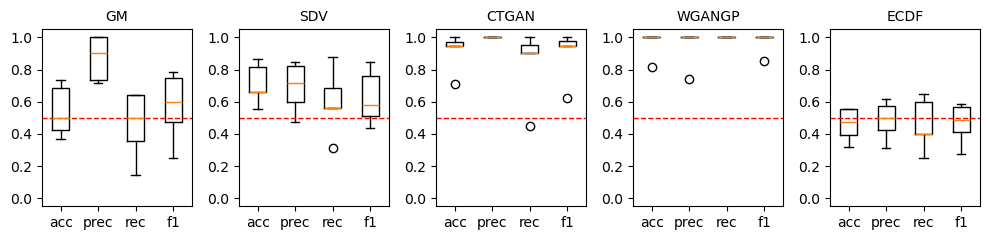

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(10, 2.5))
axs_idxs = [[0,0], [0,1], [0,2], [0,3], [0,4]]
axs_idxs = [0, 1, 2, 3, 4]
idx = dict(zip(SYNTHESIZERS,axs_idxs))

for name in SYNTHESIZERS :
    ax_plot = axs[idx[name]]
    classifiers_all[name].plot_classification_metrics(ax_plot)
    ax_plot.axhline(0.5, color='red', linestyle='--', linewidth=1)
    ax_plot.set_title(name, fontsize=10)

plt.tight_layout()
fig.savefig('DATA LABELLING RESULTS/CLASSIFICATION_METRICS.svg', bbox_inches='tight')